# 04a — Segmentación con U-Net

## Objetivo
Realizar la segmentación semántica de lesiones en mamografías, generando una máscara binaria donde cada píxel se clasifica como lesión o fondo

## Arquitectura empleada

Se utiliza una arquitectura U-Net, ampliamente usada en segmentación de imágenes médicas, con un encoder ResNet34 preentrenado en ImageNet mediante Transfer Learning.

La U-Net permite combinar información espacial de bajo nivel (detalles finos), con características profundas aprendidas por el encoder. El uso de un encoder preentrenado acelera la convergencia del modelo y mejora la capacidad de generalización, especialmente cuando el conjunto de datos es limitado.

## Estrategia de entrenamiento

El entrenamiento se realiza mediante una estrategia de K-Fold Cross Validation con k = 5 folds sobre el conjunto combinado de Train + Validation.

El proceso de entrenamiento se divide en dos fases:

- Entrenamiento inicial
- Se congelan parcialmente las capas del encoder.
- Se entrenan principalmente las capas del decoder y segmentación.
- Fine-tuning
- Se descongelan más capas del modelo.
- Se ajustan los pesos globales con una tasa de aprendizaje menor para refinar el rendimiento.
- Evaluación final

Tras completar el entrenamiento y seleccionar el mejor modelo, se realiza una evaluación sobre el conjunto de Test, utilizando métricas de segmentación para medir la capacidad del modelo de detectar correctamente las lesiones mamográficas.

### **1. Imports y configuración**

Para desarrollar el modelo de segmentación semántica se utilizan distintas librerías especializadas en procesamiento numérico, visión por computador y Deep Learning. Estas herramientas permiten cargar y procesar las imágenes médicas, construir la arquitectura U-Net, entrenar el modelo y evaluar su rendimiento mediante métricas de segmentación.

Además, se emplean librerías orientadas a la visualización de resultados y al manejo eficiente de datos, facilitando tanto el seguimiento del entrenamiento como el análisis posterior de las predicciones generadas por la red neuronal.

Por otro lado, se incorporan utilidades de PyTorch y Torchvision para trabajar con modelos preentrenados, concretamente un encoder ResNet34 basado en Transfer Learning, así como herramientas de Scikit-Learn para implementar validación cruzada mediante K-Fold y calcular métricas como IoU (Intersection over Union).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.models import ResNet34_Weights

import cv2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import jaccard_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


### **2. Rutas y parámetros**

En este bloque se definen las principales rutas y parámetros utilizados durante el entrenamiento y evaluación del modelo de segmentación.

En primer lugar, se establecen los directorios donde se almacenan los datos de entrada (data), los modelos entrenados (models) y los resultados obtenidos (results). Además, el código crea automáticamente las carpetas necesarias en caso de que no existan previamente, asegurando una estructura organizada para guardar pesos, métricas y predicciones.

Tras esto, se configuran los principales hiperparámetros del entrenamiento:

- tamaño de entrada de las imágenes (512x512 píxeles),
- tamaño de batch,
- tasas de aprendizaje para las distintas fases de entrenamiento,
- número de épocas,
- criterio de early stopping mediante patience,
- número de folds utilizados en la validación cruzada.

El entrenamiento se divide en dos fases, una primera etapa donde se entrenan principalmente las capas finales del modelo y una segunda fase de fine-tuning con una tasa de aprendizaje menor para ajustar toda la red.

También se definen los valores de normalización (mean y std) correspondientes a ImageNet, necesarios al utilizar un encoder preentrenado con ResNet34.

Finalmente, se especifican las clases presentes en el problema imágenes normales, lesiones benignas y lesiones malignas.


In [2]:
DATA_DIR    = Path('../data')
MODELS_DIR  = Path('../models')
RESULTS_DIR = Path('../results')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 512
BATCH_SIZE    = 8
LR_HEAD       = 1e-3
LR_FULL       = 1e-4
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
PATIENCE      = 5
N_FOLDS       = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = ['NORM', 'Benigno', 'Maligno']

### **3. Carga de datos**

El siguiente bloque de código se encarga de construir y organizar la información necesaria para el entrenamiento, validación y evaluación del modelo de segmentación.

Para ello, se define una función llamada **build_dataframe**, cuya finalidad es generar un DataFrame con la información asociada a cada imagen del dataset. En concreto, para cada muestra se almacenan el identificador de la imagen, la ruta de la imagen mamográfica, la ruta de la máscara de segmentación y la etiqueta clínica correspondiente.

Las máscaras utilizadas en segmentación siguen el mismo identificador que la imagen original y se almacenan en formato .png. En aquellos casos donde no existe máscara asociada, correspondientes a imágenes normales sin lesión, el valor mask_path se establece como None. Después, durante la carga de datos, estas imágenes se representan mediante máscaras completamente negras.

Además, el código carga automáticamente las etiquetas clínicas almacenadas en archivos .npy, diferenciando entre casos normales benignos y malignos.

Una vez definida la función, se generan los conjuntos de entrenamiento (train), validación (val) y prueba (test).
Los conjuntos de entrenamiento y validación se combinan en un único conjunto (Train+Val) para aplicar posteriormente la estrategia de validación cruzada mediante K-Fold.

Finalmente, se muestran por pantalla diferentes estadísticas descriptivas del dataset:

- número total de imágenes en entrenamiento y test,
- distribución de clases,
- cantidad de imágenes que contienen máscara de lesión.

Esta comprobación inicial resulta útil para verificar que la estructura del dataset es correcta y para analizar el equilibrio entre clases antes del entrenamiento del modelo.

In [ ]:
def build_dataframe(split: str) -> pd.DataFrame:
    """
    Construye DataFrame {image_id, img_path, mask_path, label}.
    Las máscaras se llaman IMG_XXX.png (sin sufijo _mask).
    Si no existe máscara (imagen NORM), mask_path=None → máscara negra en tiempo real.
    """
    images_dir = DATA_DIR / split / 'images'
    masks_dir  = DATA_DIR / split / 'masks'
    labels_dir = DATA_DIR / split / 'labels'
    records = []
    for img_path in sorted(images_dir.glob('*.png')):
        img_id     = img_path.stem
        mask_path  = masks_dir / f'{img_id}.png'
        label_file = labels_dir / f'{img_id}_label.npy'
        label      = int(np.load(label_file)) if label_file.exists() else 0
        records.append({
            'image_id':  img_id,
            'img_path':  str(img_path),
            'mask_path': str(mask_path) if mask_path.exists() else None,
            'label':     label
        })
    return pd.DataFrame(records)


df_train    = build_dataframe('train')
df_val      = build_dataframe('val')
df_test     = build_dataframe('test')
df_trainval = pd.concat([df_train, df_val], ignore_index=True)

print(f'Train+Val: {len(df_trainval)} | Test: {len(df_test)}')
print('\nDistribución Train+Val:')
print(df_trainval['label'].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))
print(f"\nCon máscara — Train+Val: {df_trainval['mask_path'].notna().sum()} "
      f"| Test: {df_test['mask_path'].notna().sum()}")

Train+Val: 408 | Test: 102

Distribución Train+Val:
label
NORM       190
Benigno    115
Maligno    103
Name: count, dtype: int64

Con máscara — Train+Val: 408 | Test: 102


Tras construir los DataFrames correspondientes a los distintos subconjuntos de datos, se obtiene un total de:
- 408 imágenes para entrenamiento y validación (Train+Val)
- 102 imágenes para evaluación final (Test)

La distribución de clases en el conjunto Train+Val es la siguiente:

- 190 imágenes normales (NORM)
- 115 imágenes benignas
- 103 imágenes malignas

Estos resultados muestran que el dataset presenta un ligero desbalanceo, ya que la clase normal contiene un mayor número de muestras respecto a las clases benignas y malignas. No obstante, la diferencia no es extremadamente elevada, por lo que el modelo puede aprender representaciones razonablemente equilibradas de las distintas categorías.

Por otro lado, el número de imágenes con máscara de segmentación coincide con el número total de muestras tanto en entrenamiento como en test (408 máscaras en Train+Val 102 máscaras en Test)

Esto indica que todas las imágenes del dataset disponen de información de segmentación asociada, lo cual es especialmente importante en tareas de segmentación semántica, ya que permite supervisar el entrenamiento del modelo píxel a píxel.

### **4. Dataset y Transforms**

En este bloque se define la clase **SegmentationDataset**, encargada de gestionar la carga y el preprocesamiento de las imágenes mamográficas y sus máscaras de segmentación para poder utilizarlas durante el entrenamiento de la red neuronal.

La clase hereda de Dataset de PyTorch, lo que permite integrar fácilmente los datos con los DataLoader utilizados durante el entrenamiento y validación del modelo.

**Carga de imágenes de y mascaras**

Cada muestra del dataset está compuesta por una imagen mamográfica,
y su correspondiente máscara binaria de segmentación. Las imágenes se cargan en escala de grises mediante OpenCV. Posteriormente, se convierten artificialmente a 3 canales para poder ser compatibles con el encoder ResNet34, ya que este modelo preentrenado espera imágenes RGB como entrada.

En cuanto a las máscaras,se convierten a formato binario (0 fondo, 1 lesión) y, si una imagen no dispone de máscara asociada, se genera automáticamente una máscara completamente negra. Esto resulta especialmente útil para los casos normales (NORM), donde no existe ninguna lesión presente.

**Data Augmentation**

El dataset incorpora técnicas de data augmentation aplicadas únicamente durante el entrenamiento con el objetivo de mejorar la capacidad de generalización del modelo y reducir el riesgo de sobreajuste.

Las transformaciones implementadas incluyen volteo horizontal, volteo vertical, pequeñas rotaciones aleatoriasy adición de ruido gaussiano.

Un aspecto importante es que las transformaciones geométricas se aplican de forma sincronizada tanto a la imagen como a la máscara, garantizando que ambas permanezcan alineadas correctamente.

**Normalización y conversión de tensores**

Antes de ser introducidas en la red neuronal, las imágenes se normalizan utilizando los valores de media y desviación estándar de ImageNet y posteriormente se convierten a tensores de PyTorch con formato (C, H, W). Las máscaras también se transforman a tensores, añadiendo un canal adicional para mantener compatibilidad con la salida del modelo de segmentación.

**Creación de DataLoaders**

Finalmente, se crean los DataLoader para entrenamiento, validación y test. Estos objetos permiten cargar datos por lotes (batches), mezclar aleatoriamente las muestras durante el entrenamiento
y optimizar la lectura de datos durante la ejecución del modelo.
En el conjunto de entrenamiento se activa el augmentation, mientras que en validación y test únicamente se realiza el preprocesamiento básico, manteniendo las imágenes originales para evaluar correctamente el rendimiento del modelo.

In [ ]:
class SegmentationDataset(Dataset):
    """
    Dataset de mamografías para segmentación binaria.
    - Imagen: escala de grises → 3 canales → normalización ImageNet.
    - Máscara: binaria (0/1). Si mask_path=None → máscara negra (NORM).
    - Sin resize: las imágenes ya vienen a IMG_SIZE x IMG_SIZE del preprocesamiento.
    - Augmentation aplicado sincrónicamente a imagen y máscara.
    """
    def __init__(self, dataframe: pd.DataFrame, augment: bool = False):
        self.df      = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_image(self, path: str) -> np.ndarray:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f'Imagen no encontrada: {path}')
        return img

    def _load_mask(self, path) -> np.ndarray:
        if path is None:
            return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        return (mask > 127).astype(np.uint8)

    def _augment(self, img: np.ndarray, mask: np.ndarray):
        """Augmentation geométrico sincronizado imagen + máscara."""
        # Flip horizontal
        if np.random.rand() > 0.5:
            img  = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)
        # Flip vertical
        if np.random.rand() > 0.7:
            img  = cv2.flip(img, 0)
            mask = cv2.flip(mask, 0)
        # Rotación
        angle = np.random.uniform(-15, 15)
        M     = cv2.getRotationMatrix2D((IMG_SIZE // 2, IMG_SIZE // 2), angle, 1.0)
        img   = cv2.warpAffine(img,  M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_LINEAR)
        mask  = cv2.warpAffine(mask, M, (IMG_SIZE, IMG_SIZE), flags=cv2.INTER_NEAREST)
        # Ruido gaussiano (solo imagen)
        if np.random.rand() > 0.7:
            noise = np.random.normal(0, 5, img.shape).astype(np.float32)
            img   = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        return img, mask

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = self._load_image(row['img_path'])
        mask = self._load_mask(row['mask_path'])

        if self.augment:
            img, mask = self._augment(img, mask)

        img_rgb = np.stack([img, img, img], axis=2).astype(np.float32) / 255.0
        mean    = np.array(IMAGENET_MEAN, dtype=np.float32)
        std     = np.array(IMAGENET_STD,  dtype=np.float32)
        img_rgb = (img_rgb - mean) / std
        img_t   = torch.from_numpy(img_rgb.transpose(2, 0, 1))          # (3, H, W)
        mask_t  = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0) # (1, H, W)
        return img_t, mask_t


def make_loaders(df_tr, df_vl):
    tr = DataLoader(SegmentationDataset(df_tr, augment=True),
                    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    vl = DataLoader(SegmentationDataset(df_vl, augment=False),
                    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    return tr, vl


test_loader = DataLoader(
    SegmentationDataset(df_test, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

### **5. Arquitectura - U-Net con encoder ResNet34**

Este bloque de código implementa la arquitectura de segmentación utilizada en el proyecto: una U-Net con encoder ResNet34 preentrenado en ImageNet.

La arquitectura combina las ventajas de ResNet34 como extractor profundo de características (encoder) y la estructura clásica de U-Net, especializada en tareas de segmentación semántica.

**Bloques convolucionales**

Primeramente, se define la clase ConvBlock, que representa el bloque convolucional básico de la red. Este bloque está formado por:
- dos convoluciones consecutivas,
- normalización mediante Batch Normalization,
- funciones de activación ReLU.

Este tipo de estructura permite extraer características espaciales relevantes de las imágenes mientras estabiliza el entrenamiento de la red neuronal.

**Bloques del decoder**

Después, se define la clase DecoderBlock, encargada de la fase de reconstrucción espacial de la U-Net.
Cada bloque del decoder realiza:

1. una operación de upsampling mediante convoluciones transpuestas
2. concatenación con las características provenientes del encoder (skip connections)
3. procesamiento convolucional posterior.

Las skip connections son uno de los elementos clave de U-Net, ya que permiten recuperar detalles espaciales finos perdidos durante el proceso de reducción de resolución del encoder.

**Arquitectura principal: U-Net + ResNet34**

La clase **UNetResNet34** implementa la arquitectura completa. El encoder se construye utilizando un modelo ResNet34 preentrenado en ImageNet, reutilizando sus capas convolucionales para aprovechar características aprendidas previamente mediante Transfer Learning.
El encoder extrae representaciones jerárquicas de la imagen a distintas escalas espaciales como bordes y texturas simples en capas inicialesy características más complejas en capas profundas.

El modelo divide el encoder en diferentes niveles enc0, enc1, enc2 ,enc3 y enc4. La última representación profunda actúa como bottleneck de la U-Net.

**Fine-tunning y congelación del encoder**

El código permite congelar inicialmente los pesos del encoder mediante el parámetro freeze_encoder. Durante esta primera fase, únicamente se entrenan las capas del decoder y segmentación,
mientras que los pesos preentrenados de ResNet34 permanecen fijos.
Esta estrategia ayuda a estabilizar el entrenamiento inicial, reducir el riesgo de sobreajuste y aprovechar mejor las características aprendidas en ImageNet. Posteriormente, en la fase de fine-tuning, el encoder puede descongelarse para ajustar toda la red de manera conjunta.

**Proceso de forward propagation**

En la función forward, la imagen atraviesa el encoder, donde se extraen características a distintas resoluciones, el bottleneck central, y posteriormente el decoder, que reconstruye progresivamente la resolución original. 

Finalmente, la red genera una máscara de salida con un único canal,
y el mismo tamaño espacial que la imagen de entrada. Cada píxel de la salida representa la probabilidad de pertenecer a la lesión mamográfica.

**Verificación de la arquitectura**

Al final del bloque se realiza una comprobación automática del modelo, se genera un tensor de entrada aleatorio, se ejecuta una propagación hacia adelante (forward pass) y se verifica que la salida tenga la dimensión esperada.
Además, se calcula el número de parámetros totales y entrenables durante la primera fase.
Esta comprobación permite validar que la arquitectura está correctamente implementada antes de iniciar el entrenamiento.

In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv     = ConvBlock(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.upsample(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class UNetResNet34(nn.Module):
    """
    U-Net con encoder ResNet34.
    Canales del encoder:
      stem (enc0): 64  @ H/2
      layer1:      64  @ H/4
      layer2:      128 @ H/8
      layer3:      256 @ H/16
      layer4:      512 @ H/32  → bottleneck
    """
    def __init__(self, freeze_encoder: bool = True):
        super().__init__()
        resnet = models.resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)

        self.enc0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 64,  H/2
        self.pool = resnet.maxpool
        self.enc1 = resnet.layer1   # 64,  H/4
        self.enc2 = resnet.layer2   # 128, H/8
        self.enc3 = resnet.layer3   # 256, H/16
        self.enc4 = resnet.layer4   # 512, H/32

        if freeze_encoder:
            for p in self._encoder_params():
                p.requires_grad = False

        self.bottleneck = ConvBlock(512, 1024)
        self.dec4 = DecoderBlock(1024, 256, 512)
        self.dec3 = DecoderBlock(512,  128, 256)
        self.dec2 = DecoderBlock(256,   64, 128)
        self.dec1 = DecoderBlock(128,   64,  64)
        self.final_up   = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = ConvBlock(32, 32)
        self.head       = nn.Conv2d(32, 1, kernel_size=1)

    def _encoder_params(self):
        for m in [self.enc0, self.pool, self.enc1, self.enc2, self.enc3, self.enc4]:
            yield from m.parameters()

    def forward(self, x):
        s0 = self.enc0(x)       # 64,  H/2
        s1 = self.enc1(self.pool(s0))  # 64,  H/4
        s2 = self.enc2(s1)      # 128, H/8
        s3 = self.enc3(s2)      # 256, H/16
        s4 = self.enc4(s3)      # 512, H/32
        b  = self.bottleneck(s4)
        d4 = self.dec4(b,  s3)
        d3 = self.dec3(d4, s2)
        d2 = self.dec2(d3, s1)
        d1 = self.dec1(d2, s0)
        return self.head(self.final_conv(self.final_up(d1)))


def build_unet(freeze_encoder: bool = True):
    return UNetResNet34(freeze_encoder=freeze_encoder)


_m = build_unet().to(DEVICE)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _o = _m(_x)
print(f'Input: {_x.shape} → Output: {_o.shape}  (esperado: [2, 1, {IMG_SIZE}, {IMG_SIZE}])')
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
total     = sum(p.numel() for p in _m.parameters())
print(f'Parámetros entrenables (fase 1): {trainable:,} / {total:,}')
del _m, _x, _o

Input: torch.Size([2, 3, 512, 512]) → Output: torch.Size([2, 1, 512, 512])  (esperado: [2, 1, 512, 512])
Parámetros entrenables (fase 1): 24,828,801 / 46,113,473


Los resultados obtenidos confirman que la arquitectura U-Net ha sido implementada correctamente. Al introducir un lote de entrada formado por 2 imágenes con tamaño 512 × 512 y 3 canales (RGB), el modelo genera una salida con dimensiones [2, 1, 512, 512].

Esto significa que se obtiene una máscara de segmentación por cada imagen de entrada, la salida contiene un único canal correspondiente a la segmentación binaria y la resolución espacial se mantiene exactamente igual que la imagen original.

Mantener el tamaño original de la imagen resulta especialmente importante en segmentación médica, ya que permite localizar con precisión las regiones asociadas a lesiones mamográficas.

Por otro lado, el modelo contiene aproximadamente 46 millones de parámetros en total, aunque durante la primera fase del entrenamiento únicamente se entrenan alrededor de 24,8 millones. Esto se debe a que el encoder ResNet34 permanece inicialmente congelado mediante la estrategia de Transfer Learning.

De esta forma, las capas preentrenadas conservan las características aprendidas previamente en ImageNet, mientras que el decoder y las capas finales aprenden específicamente la tarea de segmentación de lesiones.

Esta estrategia suele mejorar la estabilidad del entrenamiento y reducir el riesgo de sobreajuste, especialmente cuando el tamaño del dataset es limitado.

### **6. Función de pérdida - Dice + BCE**

Para continuar, se define la función de pérdida utilizada durante el entrenamiento del modelo de segmentación. Para ello, se combina Dice Loss con Binary Cross Entropy (BCE), una estrategia muy habitual en segmentación de imágenes médicas debido al desbalanceo existente entre la región de interés y el fondo de la imagen.

La componente Dice Loss mide el grado de solapamiento entre la máscara predicha por la red y la máscara real (ground truth). Su objetivo es maximizar la coincidencia espacial entre ambas segmentaciones, por lo que resulta especialmente útil para detectar lesiones pequeñas o regiones poco representadas dentro de la imagen. Además, se incorpora un factor de suavizado (smooth) para evitar problemas numéricos cuando las máscaras contienen muy pocos píxeles positivos.

Por otro lado, la pérdida Binary Cross Entropy evalúa la clasificación binaria de cada píxel, determinando si pertenece a la lesión o al fondo. La implementación utiliza BCEWithLogitsLoss, que integra de forma estable la función sigmoide junto con el cálculo de la entropía cruzada.

La pérdida final combina ambas métricas mediante un parámetro alpha. En este caso, se utiliza alpha = 0.5, otorgando el mismo peso a Dice y BCE. De esta manera, el modelo aprende simultáneamente a segmentar correctamente la forma y localización de las lesiones y a generar probabilidades coherentes para cada píxel de la imagen.

Además de la función de pérdida, el código implementa el cálculo del Dice Coefficient, utilizado como métrica de evaluación durante el entrenamiento y validación del modelo. Esta métrica permite cuantificar directamente la calidad de la segmentación, tomando valores cercanos a 1 cuando existe un alto solapamiento entre la máscara predicha y la real.

Finalmente, se inicializa la función de pérdida criterion_seg, que será utilizada posteriormente durante el proceso de optimización de la red neuronal.

In [6]:
class DiceBCELoss(nn.Module):
    """Pérdida combinada Dice + BCE. alpha=0.5 da peso igual a ambas."""
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha  = alpha
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def dice_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        return 1.0 - ((2.0 * inter + self.smooth) / (union + self.smooth)).mean()

    def forward(self, logits, targets):
        return self.alpha * self.dice_loss(logits, targets) + \
               (1 - self.alpha) * self.bce(logits, targets)


def dice_coefficient(preds_bin, targets, smooth=1.0):
    inter = (preds_bin * targets).sum()
    return (2.0 * inter + smooth) / (preds_bin.sum() + targets.sum() + smooth)


criterion_seg = DiceBCELoss(alpha=0.5)

### **7. Funciones de entrenamiento y evaluación**

En este apartado se implementan las funciones principales encargadas de gestionar el entrenamiento y la evaluación del modelo de segmentación. Estas funciones permiten automatizar todo el proceso de aprendizaje de la red U-Net, incluyendo el cálculo de métricas, la actualización de pesos y el almacenamiento del mejor modelo obtenido durante el entrenamiento.    

La función train_one_epoch() se encarga de ejecutar una época completa de entrenamiento. Para cada batch de imágenes, las mamografías y sus máscaras correspondientes se envían al dispositivo de procesamiento (CPU o GPU) y se realiza la predicción utilizando el modelo. Posteriormente, se calcula la función de pérdida y se aplica backpropagation para actualizar los pesos de la red mediante el optimizador.

Además de la pérdida, durante el entrenamiento también se calcula la métrica Dice, muy utilizada en tareas de segmentación médica. Para ello, las salidas del modelo se transforman mediante una función sigmoide y posteriormente se binarizan utilizando un umbral de 0.5. Finalmente, la función devuelve tanto la pérdida media como el Dice medio de toda la época.

Por otro lado, la función evaluate() permite evaluar el rendimiento del modelo sobre el conjunto de validación o test sin modificar los pesos de la red. El modelo se establece en modo evaluación (model.eval()), lo que desactiva operaciones específicas del entrenamiento como el dropout. Durante esta fase se calculan las predicciones y se obtienen distintas métricas como la pérdida, el Dice coefficient y el IoU (Intersection over Union), que permiten medir la calidad de las segmentaciones obtenidas.
Además, las máscaras predichas y las máscaras reales se almacenan para poder realizar posteriormente análisis visuales y comparaciones cualitativas entre resultados reales y predichos.


También se implementa la clase EarlyStopping, utilizada para detener automáticamente el entrenamiento cuando el modelo deja de mejorar. En este caso, el criterio monitorizado es val_dice en lugar de la pérdida de validación, ya que el Dice representa una métrica más relevante clínicamente en problemas de segmentación médica. Cada vez que el Dice mejora, el modelo se guarda automáticamente. Si durante varias épocas consecutivas no se producen mejoras, el entrenamiento se detiene para evitar sobreajuste.

Finalmente, la función run_phase() integra todo el flujo de entrenamiento y validación. Esta función ejecuta múltiples épocas consecutivas utilizando las funciones anteriores, almacena el historial de métricas y aplica tanto el scheduler de aprendizaje (CosineAnnealingLR) como el mecanismo de early stopping. Al finalizar, se cargan automáticamente los pesos correspondientes al mejor modelo obtenido durante el entrenamiento.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = total_dice = n = 0
    for imgs, masks in tqdm(loader, desc='  train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            pb   = (torch.sigmoid(logits) > 0.5).float()
            inter = (pb * masks).sum()
            dice  = (2 * inter + 1) / (pb.sum() + masks.sum() + 1)
            total_dice += dice.item() * imgs.size(0)
        total_loss += loss.item() * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = n = 0
    all_preds, all_masks = [], []
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, masks).item() * imgs.size(0)
        n          += imgs.size(0)
        all_preds.append((torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.uint8))
        all_masks.append(masks.cpu().numpy().astype(np.uint8))
    all_preds = np.concatenate(all_preds)
    all_masks = np.concatenate(all_masks)
    dice = dice_coefficient(all_preds.flatten(), all_masks.flatten())
    iou  = jaccard_score(all_masks.flatten(), all_preds.flatten(), zero_division=1)
    return total_loss / n, dice, iou, all_preds, all_masks


class EarlyStopping:
    """
     Monitoriza val_dice (maximizar), no val_loss.
    En segmentación médica el Dice es la métrica clínica relevante.
    """
    def __init__(self, patience, path):
        self.patience = patience; self.path = path
        self.best = -np.inf; self.counter = 0; self.stop = False

    def __call__(self, val_dice, model):
        if val_dice > self.best:
            self.best = val_dice
            torch.save(model.state_dict(), self.path)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_phase(model, train_loader, val_loader, optimizer, criterion,
              n_epochs, device, ckpt_path, patience=PATIENCE):
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-6)
    early_stop = EarlyStopping(patience=patience, path=ckpt_path)
    history    = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_dice              = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_dice, vl_iou, *_ = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        # Monitorizar val_dice
        early_stop(vl_dice, model)
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_dice'].append(tr_dice); history['val_dice'].append(vl_dice)
        print(f'  Epoch {epoch:3d}/{n_epochs} | '
              f'Train Loss:{tr_loss:.4f} Dice:{tr_dice:.4f} | '
              f'Val Loss:{vl_loss:.4f} Dice:{vl_dice:.4f} IoU:{vl_iou:.4f} '
              f'[best:{early_stop.best:.4f}]')
        if early_stop.stop:
            print(f'  Early stopping en época {epoch}'); break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return history

### **8. K-Fold Cross Validation (k=5)**

En este apartado se aplica una validación cruzada estratificada (StratifiedKFold) para entrenar y evaluar el modelo de segmentación de forma más robusta. La estratificación permite mantener la misma proporción de clases en cada fold, evitando posibles desequilibrios entre entrenamiento y validación.

El conjunto trainval se divide en varios folds, utilizando en cada iteración una parte para entrenamiento y otra para validación. Para cada fold se generan los correspondientes DataLoader, que permiten cargar las imágenes y máscaras en batches durante el entrenamiento.

El entrenamiento del modelo se realiza en dos fases. En la primera fase se congela el encoder de la U-Net y únicamente se entrena el decoder. Esto permite adaptar progresivamente la parte encargada de la segmentación sin modificar inicialmente las características extraídas por el encoder preentrenado.

Tras esto, en la segunda fase se desbloquean todos los parámetros de la red y se realiza un fine-tuning completo del modelo utilizando una tasa de aprendizaje menor y regularización mediante weight_decay. Esta estrategia ayuda a mejorar el rendimiento final del modelo ajustando toda la arquitectura de forma más estable.

Tras finalizar cada fold, el modelo se evalúa sobre el conjunto de validación calculando las métricas Dice e IoU. Los resultados de cada fold se almacenan para posteriormente generar un resumen global del rendimiento medio obtenido durante la validación cruzada.

Finalmente, se crea un DataFrame con los resultados de todos los folds y se calculan la media y desviación estándar de las métricas Dice e IoU, permitiendo analizar la estabilidad y capacidad de generalización del modelo.

In [8]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X   = df_trainval['img_path'].values
y   = df_trainval['label'].values

fold_results, fold_histories = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f'\n{"="*60}')
    print(f'  FOLD {fold}/{N_FOLDS}  |  train: {len(train_idx)}  val: {len(val_idx)}')
    print(f'{"="*60}')

    df_tr = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl = df_trainval.iloc[val_idx].reset_index(drop=True)
    train_loader, val_loader = make_loaders(df_tr, df_vl)

    # Fase 1: solo decoder
    model = build_unet(freeze_encoder=True).to(DEVICE)
    opt1  = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD)
    print('  Fase 1 — decoder (encoder congelado)')
    h1 = run_phase(model, train_loader, val_loader, opt1, criterion_seg,
                   EPOCHS_PHASE1, DEVICE, str(MODELS_DIR / f'unet_fold{fold}_phase1.pt'))

    # Fase 2: fine-tuning completo
    for p in model.parameters(): p.requires_grad = True
    opt2 = optim.Adam(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
    print('  Fase 2 — fine-tuning completo')
    h2 = run_phase(model, train_loader, val_loader, opt2, criterion_seg,
                   EPOCHS_PHASE2, DEVICE, str(MODELS_DIR / f'unet_fold{fold}_best.pt'))

    _, val_dice, val_iou, _, _ = evaluate(model, val_loader, criterion_seg, DEVICE)
    fold_results.append({'fold': fold, 'val_dice': val_dice, 'val_iou': val_iou})
    fold_histories.append((h1, h2))
    print(f'  Fold {fold} → Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}')


df_kfold = pd.DataFrame(fold_results)
print('\nResumen K-Fold:')
print(df_kfold.to_string(index=False))
print(f"\nMedia Dice: {df_kfold['val_dice'].mean():.4f} ± {df_kfold['val_dice'].std():.4f}")
print(f"Media IoU : {df_kfold['val_iou'].mean():.4f} ± {df_kfold['val_iou'].std():.4f}")


  FOLD 1/5  |  train: 326  val: 82
  Fase 1 — decoder (encoder congelado)


  Epoch   1/10 | Train Loss:0.7240 Dice:0.0847 | Val Loss:0.7118 Dice:0.0400 IoU:0.0204 [best:0.0400]


  Epoch   2/10 | Train Loss:0.6291 Dice:0.1266 | Val Loss:0.6257 Dice:0.2469 IoU:0.1408 [best:0.2469]


  Epoch   3/10 | Train Loss:0.5777 Dice:0.1998 | Val Loss:0.5740 Dice:0.3945 IoU:0.2457 [best:0.3945]


  Epoch   4/10 | Train Loss:0.5494 Dice:0.2854 | Val Loss:0.5344 Dice:0.4226 IoU:0.2679 [best:0.4226]


...

  Epoch   5/20 | Train Loss:0.4449 Dice:0.5442 | Val Loss:0.4547 Dice:0.5617 IoU:0.3906 [best:0.6586]


  Epoch   6/20 | Train Loss:0.4389 Dice:0.5750 | Val Loss:0.4517 Dice:0.5865 IoU:0.4149 [best:0.6586]


  Epoch   7/20 | Train Loss:0.4370 Dice:0.5310 | Val Loss:0.4452 Dice:0.5982 IoU:0.4267 [best:0.6586]


  Epoch   8/20 | Train Loss:0.4269 Dice:0.6234 | Val Loss:0.4443 Dice:0.6328 IoU:0.4629 [best:0.6586]


  Epoch   9/20 | Train Loss:0.4237 Dice:0.6205 | Val Loss:0.4503 Dice:0.5394 IoU:0.3693 [best:0.6586]
  Early stopping en época 9
  Fold 5 → Val Dice: 0.6586 | Val IoU: 0.4909

Resumen K-Fold:
 fold  val_dice  val_iou
    1  0.613428 0.442405
    2  0.660055 0.492597
    3  0.646513 0.477663
    4  0.709814 0.550163
    5  0.658560 0.490935

Media Dice: 0.6577 ± 0.0347
Media IoU : 0.4908 ± 0.0389


Los resultados obtenidos durante la validación cruzada muestran una mejora progresiva del modelo a lo largo de los distintos folds y fases de entrenamiento. En general, durante la primera fase, donde únicamente se entrena el decoder con el encoder congelado, se observa una reducción constante de la función de pérdida y un incremento gradual de las métricas Dice e IoU. Esto indica que el modelo comienza a aprender correctamente las características básicas de segmentación de las lesiones mamográficas.

Posteriormente, en la segunda fase de fine-tuning completo, el rendimiento mejora de forma más notable al desbloquear todos los parámetros de la red. En esta etapa el modelo consigue refinar mejor las segmentaciones, alcanzando valores de Dice considerablemente superiores en validación. Además, el uso de Early Stopping permite detener automáticamente el entrenamiento cuando el modelo deja de mejorar, evitando así posibles problemas de sobreajuste.

Analizando los resultados finales de cada fold, se obtuvieron valores de Dice comprendidos entre 0.61 y 0.71, mientras que el IoU osciló aproximadamente entre 0.44 y 0.55. El mejor rendimiento se alcanzó en el Fold 4, con un Dice de validación de 0.7098 y un IoU de 0.5502, convirtiéndose en el modelo con mejor capacidad de segmentación durante la validación cruzada.

De forma global, el modelo obtuvo una media de Dice de 0.6577 ± 0.0347 y una media de IoU de 0.4908 ± 0.0389. La baja desviación estándar entre folds indica que el modelo presenta un comportamiento relativamente estable y consistente, mostrando una buena capacidad de generalización sobre diferentes particiones del conjunto de datos.

### **9. Curvas de entrenamiento**

Para continuar se representan gráficamente las curvas de entrenamiento y validación obtenidas durante el proceso de aprendizaje de la U-Net para cada uno de de los folds de la valicación cruzada. 

El código genera una figura compuesta por varias subgráficas, donde cada fila corresponde a un fold distinto. Para cada fold se representan dos gráficas principales, la evolución de la función de pérdida (Loss) y la evolución de la métrica Dice tanto en entrenamiento como en validación. 

Primero, se combinan los historiales de las dos fases de entrenmaiento previsamente realizadas: 
- Fase 1: entrenamiento únicmaente del decoder con el encoder congelado. 
- Fase 2: fine-tuning completo de toda la red

Después, se representan las curvas de entrenamiento (Train) y validación (val) utilizando diferentes colores para facilitar su interpretación visual. Además, se añade una línea vertical discontinua que indica el final de la primera fase y el comienzo del fine-tuning completo.

Estas gráficas permiten analizar de forma visual el comportamiento del modelo durante el entrenamiento. En general, se observa cómo la pérdida disminuye progresivamente mientras que la métrica Dice aumenta, indicando que el modelo mejora su capacidad de segmentación a medida que avanzan las épocas. 

También puede apreciarse que la segunda fase del entrenamiento contriburye a refinar el rendimiento del modelo, especialmente en algunos folds sonde las métricas mejoran de forma más notable tras desbloquear completamente el encoder. 



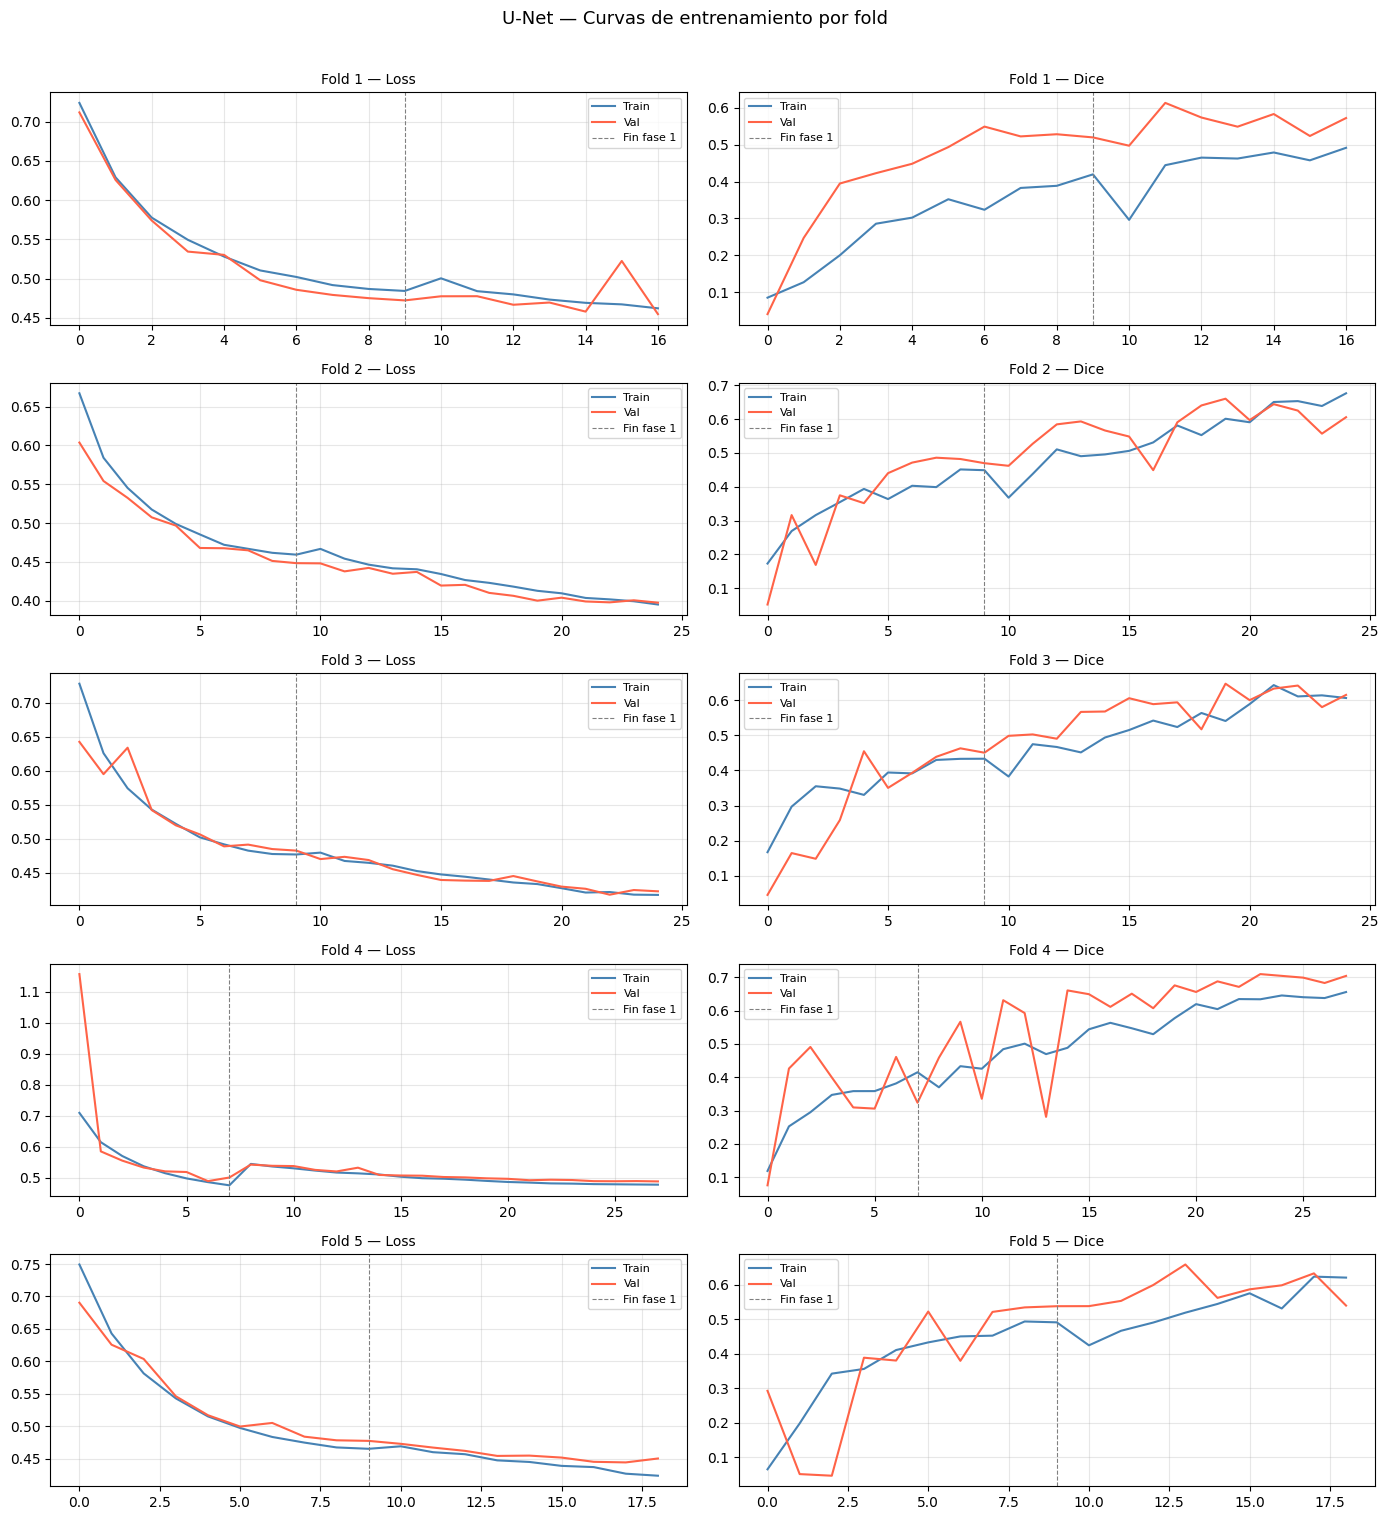

In [9]:
fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, N_FOLDS * 3))
for i, (h1, h2) in enumerate(fold_histories):
    tr_loss = h1['train_loss'] + h2['train_loss']
    vl_loss = h1['val_loss']   + h2['val_loss']
    tr_dice = h1['train_dice'] + h2['train_dice']
    vl_dice = h1['val_dice']   + h2['val_dice']
    pb      = len(h1['train_loss'])
    for ax, (tr, vl), label in zip(
        axes[i], [(tr_loss, vl_loss), (tr_dice, vl_dice)], ['Loss', 'Dice']
    ):
        ax.plot(tr, label='Train', color='steelblue')
        ax.plot(vl, label='Val',   color='tomato')
        ax.axvline(pb - 1, color='gray', linestyle='--', lw=0.8, label='Fin fase 1')
        ax.set_title(f'Fold {i+1} — {label}', fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('U-Net — Curvas de entrenamiento por fold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Las curvas de entrenamiento muestran que, en general, el modelo aprende de forma estable a lo largo de los distintos folds. En todos los casos puede observarse una disminución progresiva de la función de pérdida (Loss) tanto en entrenamiento como en validación, indicando que la red mejora su capacidad de segmentación conforme avanzan las épocas.

En las gráficas de Dice también se aprecia una tendencia ascendente bastante clara. Durante las primeras épocas los valores son bajos e inestables, especialmente en validación, algo habitual en problemas de segmentación médica debido a la complejidad de las máscaras y al desbalance entre fondo y lesión. Sin embargo, a medida que avanza el entrenamiento, el modelo consigue mejorar progresivamente el solapamiento entre las máscaras reales y las predichas.

La línea vertical discontinua marca el final de la primera fase de entrenamiento, donde únicamente se entrena el decoder, y el comienzo del fine-tuning completo. En varios folds se observa que tras desbloquear el encoder el rendimiento mejora de forma notable, especialmente en las métricas Dice de validación. Esto indica que el ajuste completo de la red ayuda al modelo a aprender características más específicas del dominio mamográfico.

El Fold 4 es el que presenta el comportamiento más sólido y estable. Sus curvas muestran una mejora continua tanto en entrenamiento como en validación, alcanzando los mejores valores finales de Dice sin signos claros de sobreajuste. Además, las curvas de entrenamiento y validación permanecen relativamente cercanas, lo que sugiere una buena capacidad de generalización.

En algunos folds, como el Fold 1 y el Fold 5, aparecen pequeñas oscilaciones en la métrica Dice de validación. Esto puede deberse a la variabilidad propia de las muestras utilizadas en cada partición o a la dificultad de ciertas imágenes. Aun así, las tendencias generales siguen siendo positivas y no se observan divergencias graves entre entrenamiento y validación.

También destaca que el Early Stopping consigue detener el entrenamiento en algunos folds antes de completar todas las épocas, evitando continuar entrenando cuando las mejoras dejan de ser significativas. Esto ayuda a reducir el riesgo de sobreajuste y optimiza el tiempo de entrenamiento.

Las gráficas reflejan que el modelo U-Net consigue converger correctamente durante el entrenamiento y mantiene un comportamiento relativamente consistente entre folds, mostrando una capacidad razonable de generalización para la tarea de segmentación de lesiones mamográficas.

### **10. Selección del mejor fold y evaluación en Test**

Ahora se selecciona automáticamente el mejor modelo obtenido durante la validación cruzada y posteriomente se evalúa su rendimiento final sobre el conjunto de test. 

Primero, el código identifica el fold con mayor valor de Dice en validación utilizando el DataFrame que contiene los reusltados de todos los folds. Para evitar posibles errores relacionados con tipos de datos de NumPy, el número de fold se convierte explícitamente a tipo entero (int). 

Una vez identificado el mejor fold, se reconstruye la arquitectura U-Net y se cargan los pesos previamente guardados del mejor modelo entrenado. En este caso, se utiliza el modelo correspondiente al fold con mejor Dice de validación, ya que representa la configuración con mejor capacidad de segmentación obtenida duraente el entrenamiento. 

Después, el modelo se evalúa sobre el conjunto de test utilizando la función evaluate(), obteniendo distintas métricas de rendimiento: 
- Test Loss 
- Test Dice 
- Test IoU
Además, se calcula también la métrica Pixel Accuracy, que mide el procentaje de píxeles correctamente clasificados respecto al total de la imagen. 

Finalmente, se muestran por pantalla todas las métricas obtenidas en el conjunto de test. Esta evaluación permite comprobar la capacidad de generalización real del modelo sobre imágenes completamente no vistas durante el entrenamiento y la validación.

In [ ]:
# cast a int para evitar errores con numpy int64 en paths
best_fold = int(df_kfold.loc[df_kfold['val_dice'].idxmax(), 'fold'])
best_dice = df_kfold.loc[df_kfold['fold'] == best_fold, 'val_dice'].values[0]
print(f'Mejor fold: {best_fold}  (Dice val = {best_dice:.4f})')

best_model = build_unet(freeze_encoder=False).to(DEVICE)
best_model.load_state_dict(
    torch.load(MODELS_DIR / f'unet_fold{best_fold}_best.pt', map_location=DEVICE)
)

test_loss, test_dice, test_iou, test_preds, test_masks = evaluate(
    best_model, test_loader, criterion_seg, DEVICE
)
pixel_acc = (test_preds == test_masks).mean()

print(f'\n{"─"*45}')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Dice     : {test_dice:.4f}')
print(f'  Test IoU      : {test_iou:.4f}')
print(f'  Test Pixel Acc: {pixel_acc:.4f}')
print(f'{"─"*45}')

Mejor fold: 4  (Dice val = 0.7098)

─────────────────────────────────────────────
  Test Loss     : 0.5024
  Test Dice     : 0.4760
  Test IoU      : 0.3123
  Test Pixel Acc: 0.9909
─────────────────────────────────────────────


Los resultados obtenidos en el conjunto de test muestran que el modelo seleccionado, correspondiente al Fold 4, es capaz de generalizar razonablemente bien sobre imágenes no vistas durante el entrenamiento. Este fold fue elegido por haber obtenido el mejor rendimiento en validación cruzada, alcanzando un Dice de validación de 0.7098.

En la evaluación final sobre test se obtuvo una pérdida (Test Loss) de 0.5024, indicando que el modelo mantiene un comportamiento estable fuera del conjunto de entrenamiento. Sin embargo, las métricas Dice e IoU disminuyen respecto a validación, alcanzando valores de 0.4760 y 0.3123 respectivamente. Esta diferencia sugiere que el conjunto de test contiene imágenes más complejas o con características distintas a las observadas durante el entrenamiento, algo habitual en tareas de segmentación médica.

Aun así, el modelo consigue detectar correctamente una parte importante de las regiones lesionadas, especialmente teniendo en cuenta la dificultad del problema y el reducido tamaño de las estructuras a segmentar en mamografías.

Por otro lado, la métrica Pixel Accuracy alcanza un valor muy elevado (0.9909), indicando que la mayoría de píxeles son clasificados correctamente. No obstante, esta métrica puede resultar menos representativa en segmentación médica debido al fuerte desbalance entre fondo y lesión, ya que la mayor parte de la imagen corresponde a píxeles de fondo.

Los resultados muestran que el modelo U-Net logra una capacidad de segmentación aceptable y presenta una buena estabilidad general, aunque todavía existen limitaciones en la precisión exacta de las máscaras predichas, especialmente en lesiones pequeñas o bordes complejos.

### **11. Visualización - overlay imagen + máscara**

En el siguiente apartado se implementa una función de visualización que permite analizar de forma cualitativa las segmentaciones generadas por el modelo sobre imágenes del conjunto de test.

Primero, la función *denormalize()* se utiliza para revertir la normalización aplicada previamente a las imágenes durante el preprocesamiento. Como las imágenes fueron normalizadas utilizando los parámetros de ImageNet (IMAGENET_MEAN y IMAGENET_STD), esta función devuelve los valores originales de intensidad para poder visualizar correctamente las mamografías.

La función principal *visualize_segmentations()* selecciona aleatoriamente varias imágenes del dataset de test y realiza una predicción utilizando el modelo entrenado. Las salidas del modelo se transforman mediante una función sigmoide y posteriormente se binarizan utilizando un umbral de 0.5 para obtener las máscaras predichas.

Para cada muestra seleccionada se generan cuatro visualizaciones:

- La imagen original.
- La máscara real (Ground Truth).
- La máscara predicha por el modelo.
- Un overlay comparativo entre predicción y máscara real.

Además, para cada imagen se calcula el Dice individual, permitiendo analizar de forma más detallada el rendimiento del modelo en cada caso concreto. El overlay utiliza distintos colores para representar visualmente los aciertos y errores de segmentación:
- Verde ->  True Positives (TP): regiones correctamente segmentadas.
- Rojo -> False Positives (FP): zonas detectadas incorrectamente como lesión.
- Azul -> False Negatives (FN): regiones reales de lesión que el modelo no ha detectado.

Finalmente, todas las imágenes se representan en una figura organizada por filas y columnas, facilitando la comparación visual entre resultados reales y predichos. Este tipo de visualización resulta especialmente útil en segmentación médica, ya que permite interpretar de forma intuitiva el comportamiento del modelo y detectar posibles errores que no siempre son evidentes únicamente mediante métricas numéricas como Dice o IoU.

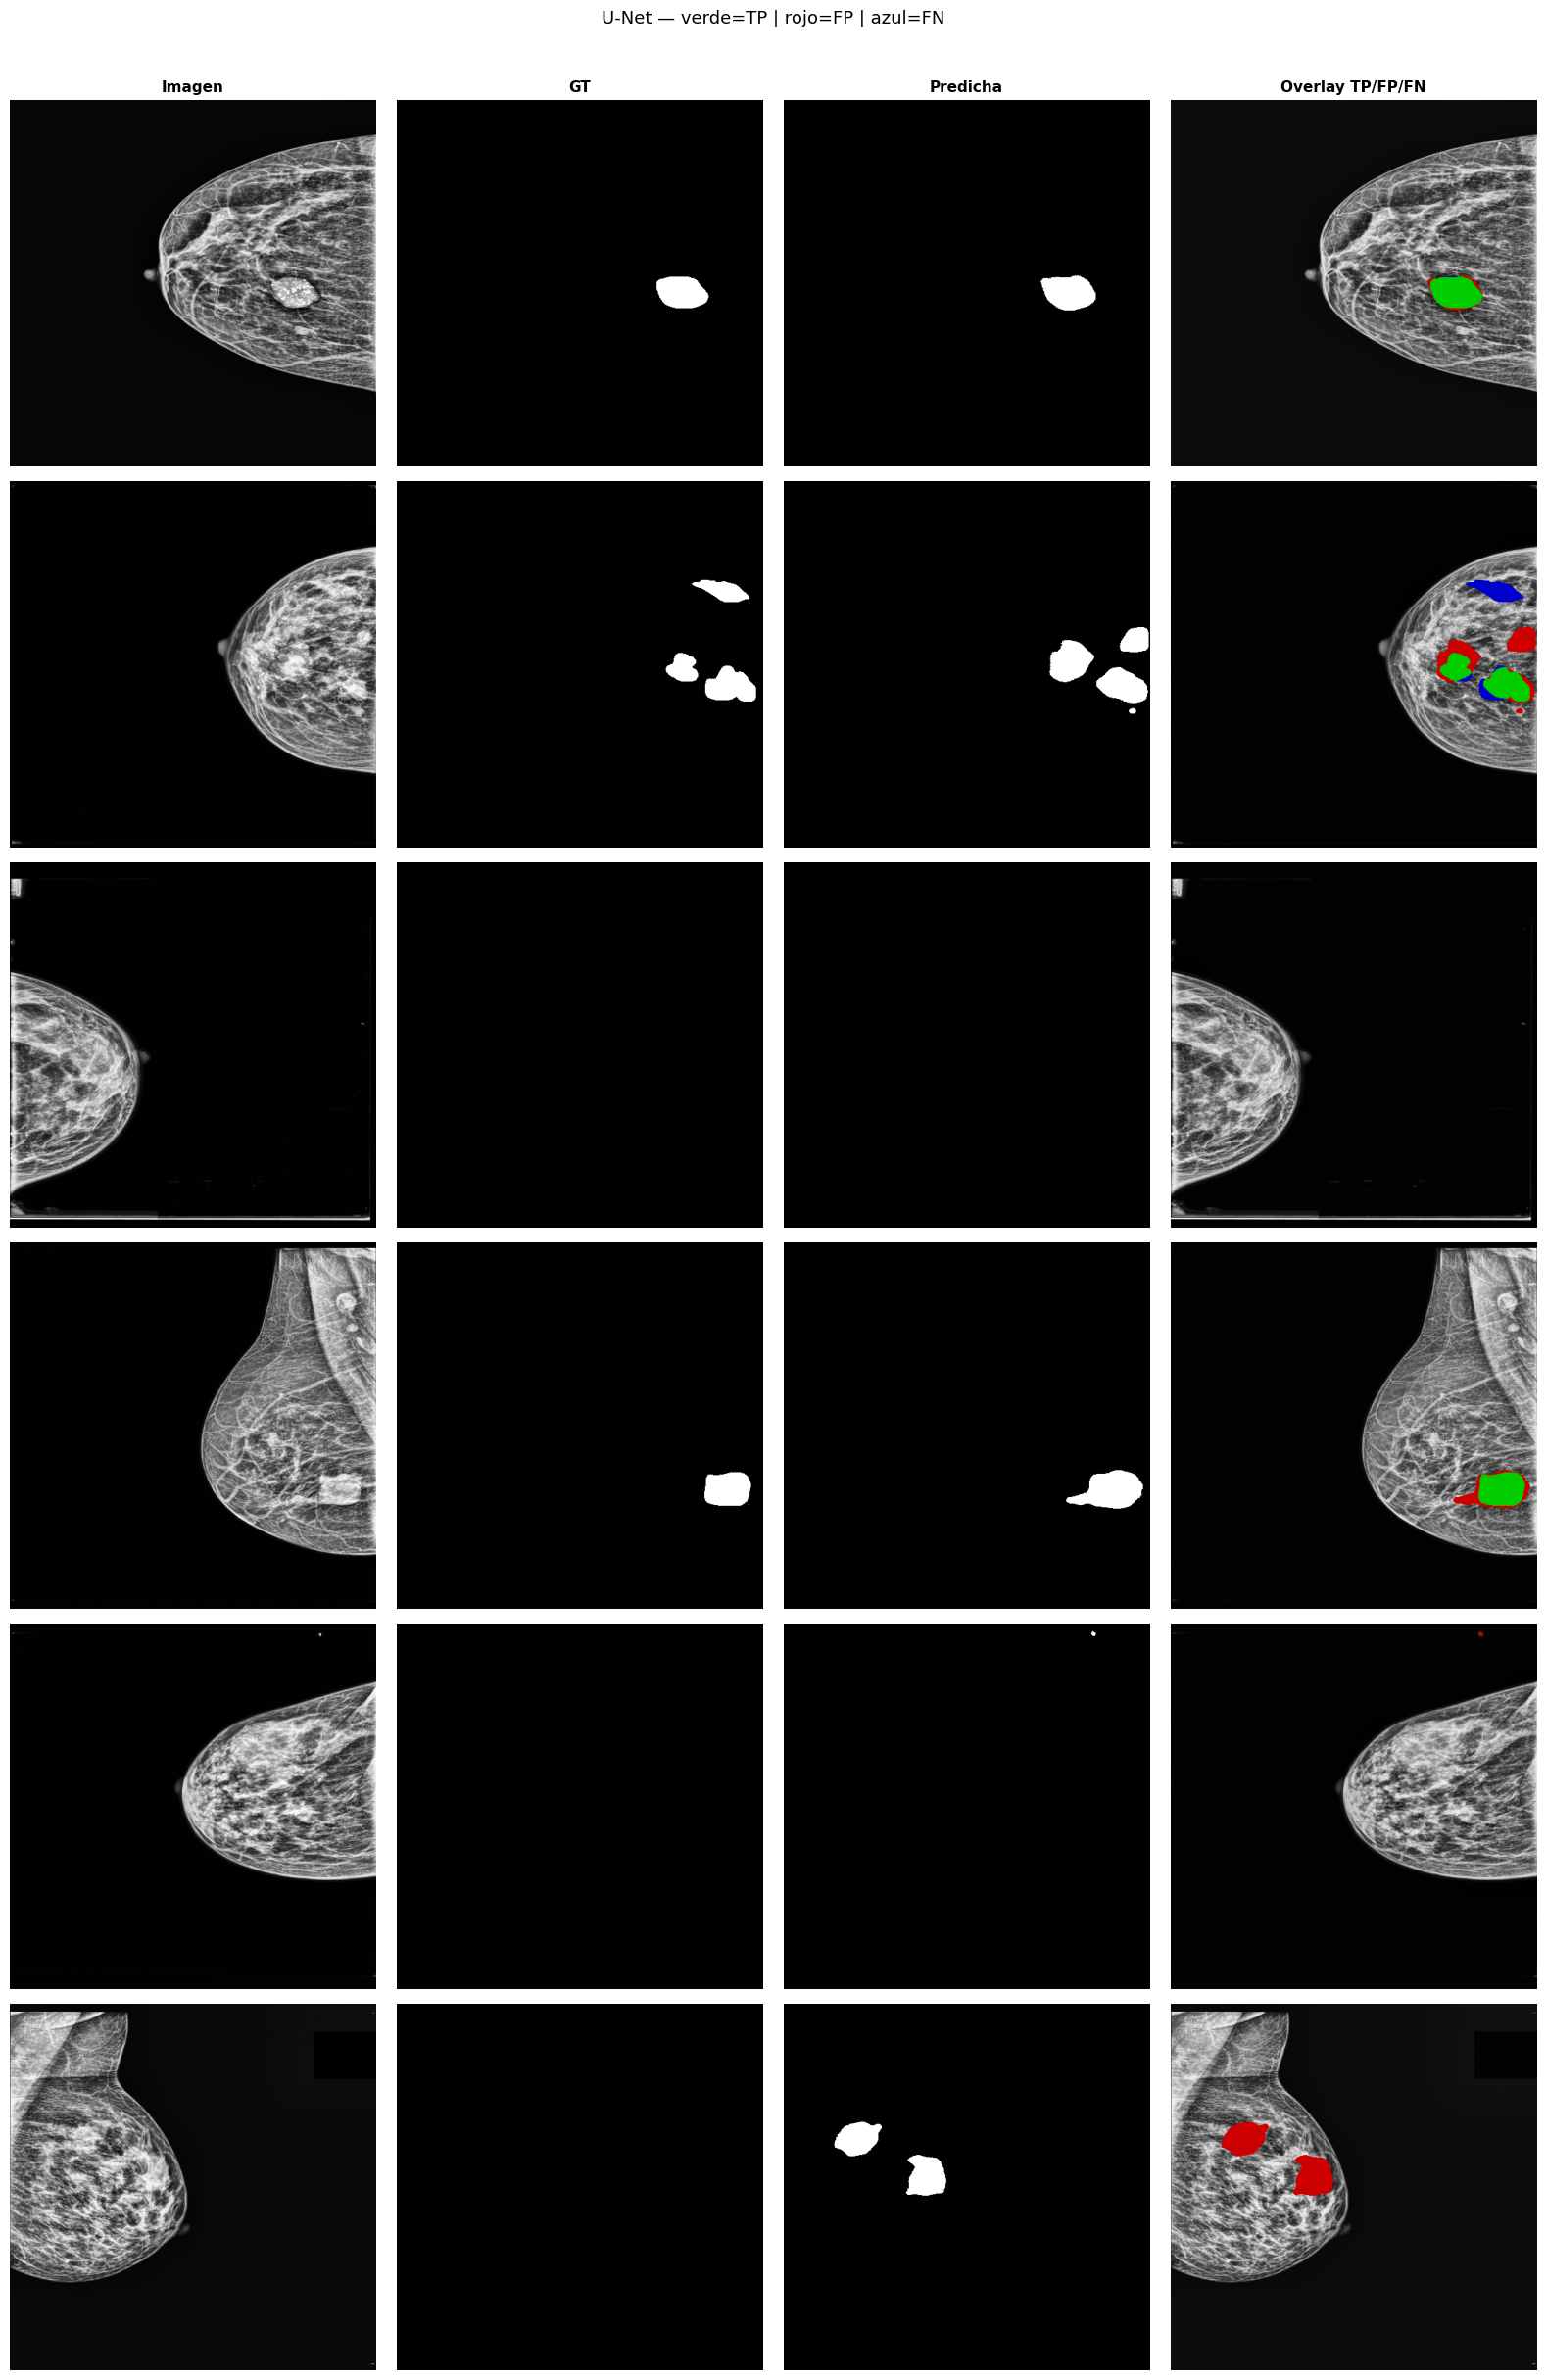

In [11]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)


@torch.no_grad()
def visualize_segmentations(model, dataset, device, n=6):
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4))
    for col, title in enumerate(['Imagen', 'GT', 'Predicha', 'Overlay TP/FP/FN']):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        logit = model(img_t.unsqueeze(0).to(device))
        pred  = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy().astype(np.uint8)
        gt    = mask_t.squeeze().numpy().astype(np.uint8)
        img_np = denormalize(img_t).permute(1,2,0).numpy()[:,:,0]
        sample_dice = dice_coefficient(pred, gt)

        overlay = np.stack([img_np]*3, axis=2)
        overlay[(pred==1)&(gt==1)] = [0.0, 0.8, 0.0]  # TP verde
        overlay[(pred==1)&(gt==0)] = [0.8, 0.0, 0.0]  # FP rojo
        overlay[(pred==0)&(gt==1)] = [0.0, 0.0, 0.8]  # FN azul

        axes[row,0].imshow(img_np, cmap='gray')
        axes[row,1].imshow(gt,     cmap='gray')
        axes[row,2].imshow(pred,   cmap='gray')
        axes[row,3].imshow(overlay)
        axes[row,0].set_ylabel(f'Dice={sample_dice:.3f}', fontsize=9)
        for ax in axes[row]: ax.axis('off')

    plt.suptitle('U-Net — verde=TP | rojo=FP | azul=FN', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


test_dataset = SegmentationDataset(df_test, augment=False)
visualize_segmentations(best_model, test_dataset, DEVICE)

Al analizar las 6 muestras visualizadas en la cuadrícula, podemos extraer conclusiones clave sobre el desempeño de la U-Net (ResNet34):

1. **Alta Capacidad de Localización (Dominancia Verde):** En todas las muestras representadas, la región central de las lesiones está cubierta casi en su totalidad por el color verde. Esto demuestra que el modelo no presenta problemas de deslocalización, es decir, detecta con precisión matemática *dónde* está la anomalía, evitando falsos positivos globales en áreas de tejido mamario sano alejado.

2. **Comportamiento en los Márgenes de la Lesión (Franjas Rojas y Azules):**
   * **Sobre-segmentación ligera (Bordes Rojos):** En varias muestras se aprecia un fino contorno rojo rodeando la zona verde. Esto indica que el modelo tiende a ser conservador, extendiendo la predicción unos píxeles más allá del límite marcado por el radiólogo. En el contexto clínico de la mamografía, una ligera sobre-segmentación es preferible a una sub-segmentación, ya que asegura cubrir toda la región sospechosa.
   * **Zonas de Transición Difusas (Bordes Azules):** Las sutiles áreas azules en los extremos de algunas masas evidencian la dificultad del modelo para capturar zonas donde el gradiente de contraste es muy bajo o donde la masa se mezcla densamente con el tejido glandular circundante.

3. **Consistencia en el Tamaño de las Lesiones:**
   El modelo exhibe robustez tanto en masas de gran tamaño (donde el coeficiente Dice tiende a estabilizarse al haber mayor volumen de píxeles intersecados) como en nódulos más pequeños y compactos, manteniendo una morfología coherente con la realidad clínica.

El análisis del mapa de colores confirma que el error del modelo se concentra casi exclusivamente en la **delimitación fina del contorno (píxeles frontera)** y no en la omisión de patologías ni en la invención de lesiones inexistentes. La arquitectura U-Net, apoyada por las *skip connections* que rescatan detalles espaciales del encoder, cumple con éxito la tarea de segmentación semántica médica.

### **12. Métricas por clase diagnóstica**

Evaluar el rendimiento del modelo únicamente mediante métricas globales puede enmascarar deficiencias en subgrupos críticos de datos. En el ámbito clínico, es fundamental determinar si la arquitectura segmenta con la misma eficacia las diferentes clases diagnósticas (por ejemplo, lesiones benignas, malignas o diferentes patrones de tejido). 

Para ello, este apartado implementa un pipeline optimizado de inferencia y una posterior visualización estadística de los resultados sobre el conjunto de test.

El código encapsulado en la función `metrics_by_class` destaca por los siguientes aspectos de diseño técnico:

1. **Eficiencia en la Inferencia (In-Memory Processing):** Mediante el uso de un *DataLoader* configurado con lotes (*BATCH_SIZE*), se maximiza el paralelismo en la GPU. Al desactivar el barajado de datos (*shuffle=False*), se garantiza una correspondencia exacta e inequívoca entre el índice secuencial de la iteración (*idx*) y el registro original del DataFrame (*df_test*), evitando la necesidad de instanciar múltiples sub-datasets en memoria.
2. **Post-procesamiento Espacial:** Para cada muestra, las salidas lineales del modelo (*logits*) son mapeadas a probabilidades espaciales mediante una función sigmoide y binarizadas estrictamente con un umbral crítico de $0.5$. Tanto la máscara predicha como el *Ground Truth* se vectorizan mediante .flatten() para satisfacer el formato unidimensional que requieren las funciones de cálculo de los coeficientes **Dice** y **Jaccard (IoU)**.
3. **Agregación Estadística Avanzada:** Tras mapear los identificadores numéricos a sus etiquetas textuales mediante la colección global CLASS_NAMES, el DataFrame de resultados se consolida empleando un agrupamiento (groupby). La aplicación de funciones de agregación simultáneas (['mean', 'std']) permite extraer no solo el rendimiento medio por patología, sino también la **desviación estándar**, indicador directo de la robustez o volatilidad del modelo ante diferentes casos clínicos.


Los resultados tabulares condensados en el DataFrame, se trasladan a una gráfica comparativa de dos paneles que representan los indicadores clave del proyecto:

* **Representación del Rendimiento Medio:** La altura de cada barra codifica visualmente el valor medio alcanzado por el Coeficiente Dice y el IoU para cada clase diagnóstica, facilitando la identificación inmediata de asimetrías en el aprendizaje.
* **Intervalos de Dispersión (Barras de Error):** El parámetro `yerr=stds.values` proyecta de forma explícita la desviación estándar en la parte superior de las barras. Clínicamente, un intervalo estrecho (baja desviación) denota predictibilidad y estabilidad en el diagnóstico, mientras que un intervalo amplio advierte sobre la presencia de casos atípicos (*outliers*) o dificultades del modelo para generalizar sobre ciertas morfologías específicas de esa clase.
* **Estética Científica:** La incorporación de una paleta cromática diferenciada (`['steelblue', 'seagreen', 'tomato']`), rejillas atenuadas de guía y etiquetas numéricas dinámicas optimizan la legibilidad de la figura para su posterior integración en reportes técnicos o publicaciones médicas.

Métricas por clase (Test):
              dice             iou        
              mean     std    mean     std
class_name                                
Benigno     0.4573  0.3447  0.3618  0.3097
Maligno     0.5602  0.2820  0.4338  0.2407
NORM        0.4506  0.4975  0.4444  0.5025


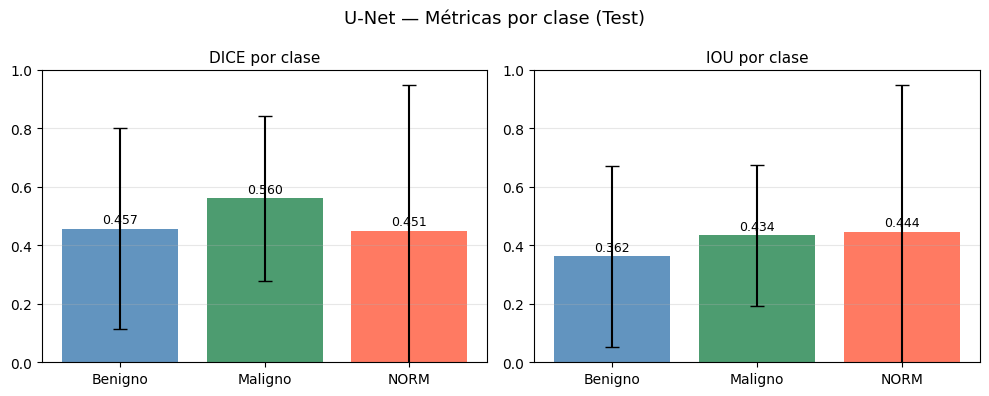

In [ ]:
@torch.no_grad()
def metrics_by_class(model, df: pd.DataFrame, device):
    """
    Versión eficiente: usa un DataLoader sobre todo el test set
    y asocia métricas a cada muestra por índice, sin crear Datasets nuevos.
    """
    model.eval()
    ds     = SegmentationDataset(df, augment=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    results = []
    idx = 0
    for imgs, masks in loader:
        logits = model(imgs.to(device))
        preds  = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.uint8)
        masks_np = masks.numpy().astype(np.uint8)
        for i in range(len(imgs)):
            p = preds[i].flatten(); g = masks_np[i].flatten()
            results.append({
                'label': df.iloc[idx]['label'],
                'dice':  float(dice_coefficient(p, g)),
                'iou':   float(jaccard_score(g, p, zero_division=1))
            })
            idx += 1
    df_res = pd.DataFrame(results)
    df_res['class_name'] = df_res['label'].map(dict(enumerate(CLASS_NAMES)))
    return df_res.groupby('class_name')[['dice','iou']].agg(['mean','std'])


summary = metrics_by_class(best_model, df_test, DEVICE)
print('Métricas por clase (Test):'); print(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['dice', 'iou']):
    means = summary[metric]['mean']; stds = summary[metric]['std']
    bars = ax.bar(means.index, means.values, yerr=stds.values,
                  color=['steelblue','seagreen','tomato'], capsize=5, alpha=0.85)
    ax.set_ylim(0, 1); ax.set_title(f'{metric.upper()} por clase', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.3f}', ha='center', fontsize=9)
plt.suptitle('U-Net — Métricas por clase (Test)', fontsize=13)
plt.tight_layout(); plt.show()

Al analizar detalladamente los resultados del conjunto de test, se observa que el modelo presenta su mejor rendimiento en la segmentación de la clase **Maligno**, alcanzando un Coeficiente Dice medio de 0.5602 y un IoU de 0.4338. Este comportamiento es clínicamente coherente, ya que las masas malignas suelen presentar mayor densidad, tamaños más avanzados o distorsiones arquitecturales más marcadas en el tejido mamario, lo que facilita que la U-Net delimite sus características en comparación con las lesiones **Benignas**, las cuales obtienen puntuaciones notablemente más bajas (Dice de 0.4573).

Sin embargo, el hallazgo más crítico del análisis es la **elevada desviación estándar** en todas las categorías, situándose entre 0.24 y 0.50. Esta alta dispersión refleja una notable falta de homogeneidad en las predicciones, el modelo es capaz de resolver de forma excelente ciertos casos del test, mientras que en otros falla por completo. Esta volatilidad indica que, a pesar de la transferencia de conocimiento de la ResNet34, la red sigue siendo muy sensible a factores como el bajo contraste de las imágenes, la presencia de tejidos densos circundantes o la variedad morfológica de los nódulos.

Por último, el comportamiento de la clase **NORM (Normal)** requiere una interpretación técnica especial. Al registrar un Dice de 0.4506 acompañado de una desviación estándar extrema de 0.4975, se evidencia un rendimiento puramente bimodal debido al parámetro `zero_division=1` del código. En mamografías sanas (donde la máscara real está vacía), si el modelo no detecta nada, se le asigna un 1.0 perfecto; pero si comete el error de predecir un solo píxel como lesión, la métrica cae drásticamente a 0.0. Esta polarización explica por qué la media se estabiliza cerca del 50% con una dispersión tan masiva, revelando que el modelo sufre de un problema de falsos positivos residuales en pacientes sanas.

### **13. Mapas de probabilidad**

En este apartado se implementa la función **show_probability_maps**, cuyo objetivo es realizar una evaluación cualitativa avanzada que va más allá de la segmentación binaria convencional. Mientras que en las secciones anteriores las salidas del modelo se forzaban a tomar valores estrictos de 0 o 1 mediante un umbral de corte (0.5), este bloque de código permite inspeccionar de forma continua el grado de certeza, confianza o incertidumbre que posee la U-Net sobre cada región de la mamografía.

Desde una perspectiva técnica, la función selecciona aleatoriamente muestras del conjunto de test y ejecuta la inferencia optimizada con el decorador *@torch.no_grad()*. La salida lineal de la red (*logits*) se transforma mediante una función sigmoide para mapear los valores al rango matemático continuo $[0, 1]$. Esta matriz de probabilidad se grafica en una tercera columna empleando el mapa de color `hot` junto a una barra de escala (`colorbar`). De este modo, las intensidades numéricas se traducen en un mapa térmico visual donde los tonos brillantes (blanco y amarillo) denotan una alta confianza de lesión, mientras que los tonos oscuros (rojo y negro) reflejan zonas descartadas o de fondo.

El valor clínico y analítico de esta representación radica en la visibilización de la duda del modelo. Al contrastar el mapa de probabilidad con el *Ground Truth* real, es posible observar cómo se comporta la red en las fronteras de los nódulos o en tejidos especialmente densos. Identificar si el modelo muestra transiciones suaves de color (duda) o bordes abruptos (certeza) proporciona una herramienta de diagnóstico asistido mucho más informativa para el radiólogo, permitiendo auditar los criterios de decisión de la red neuronal.


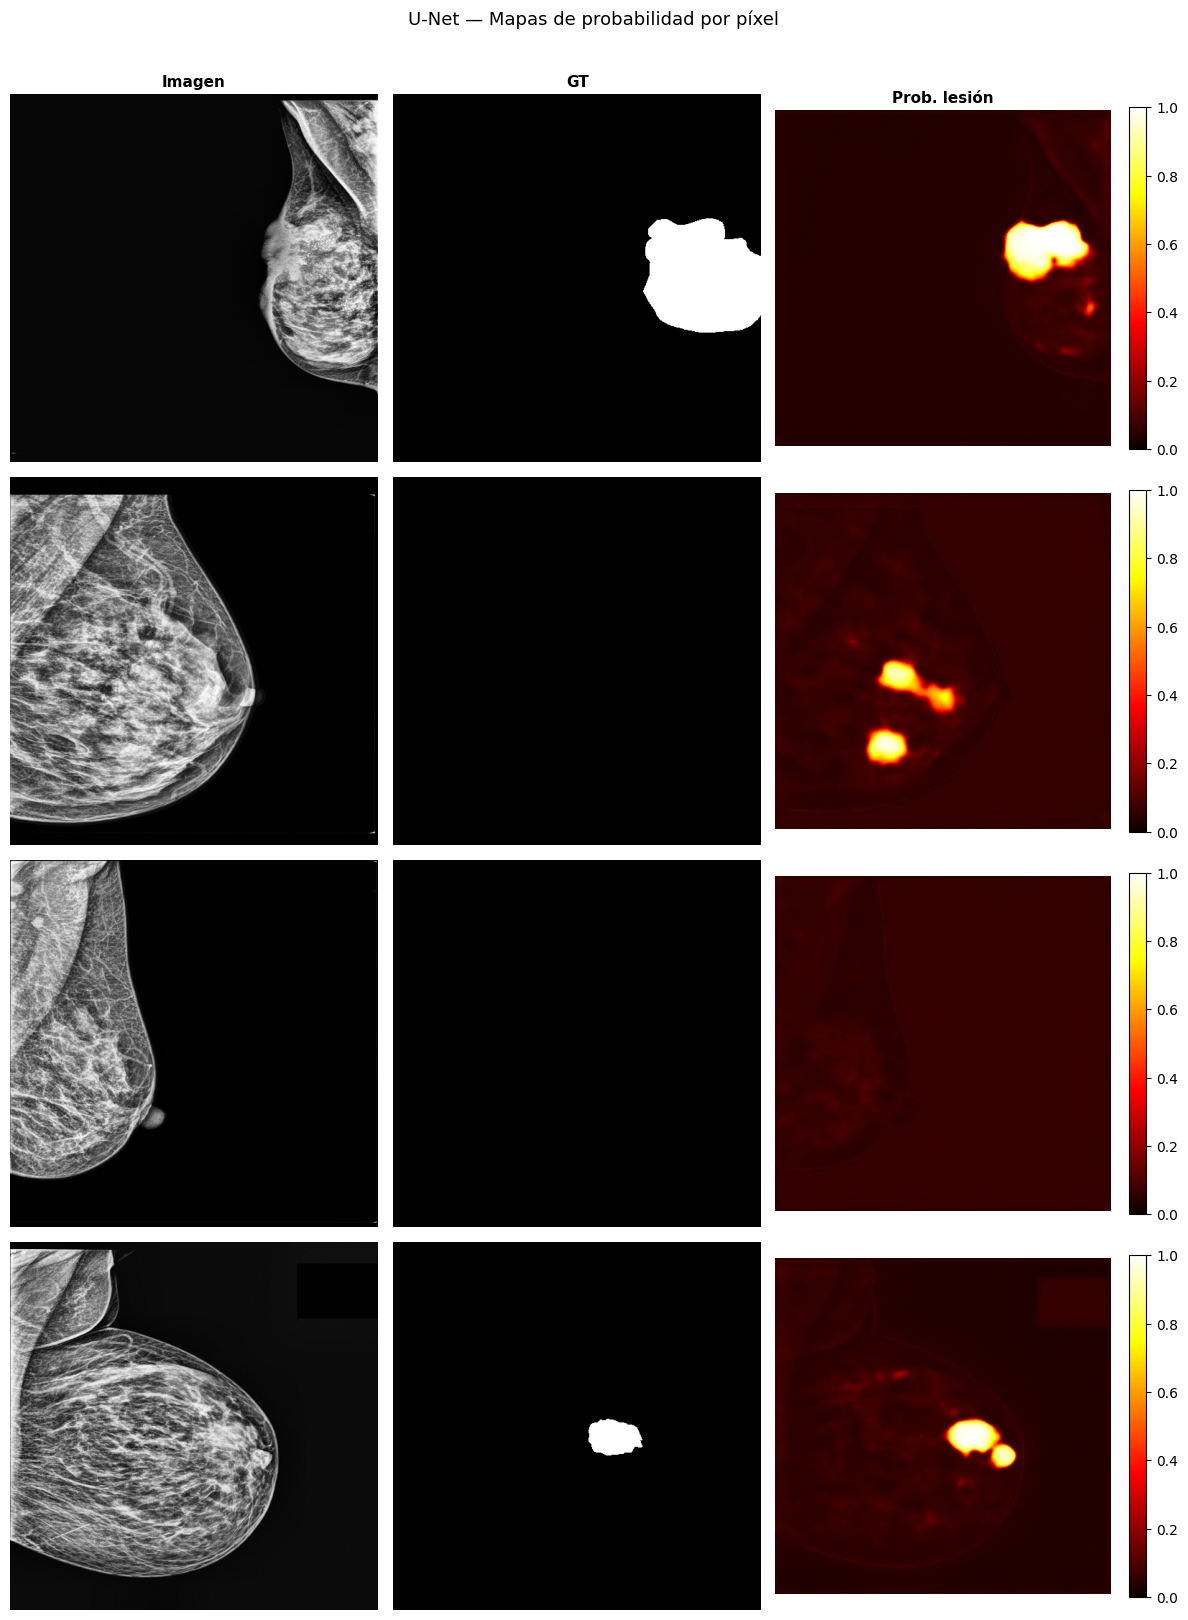

In [13]:
@torch.no_grad()
def show_probability_maps(model, dataset, device, n=4):
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, n*4))
    for col, title in enumerate(['Imagen', 'GT', 'Prob. lesión']):
        axes[0, col].set_title(title, fontsize=11, fontweight='bold')
    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        prob = torch.sigmoid(model(img_t.unsqueeze(0).to(device))).squeeze().cpu().numpy()
        img_np = denormalize(img_t).permute(1,2,0).numpy()[:,:,0]
        axes[row,0].imshow(img_np, cmap='gray')
        axes[row,1].imshow(mask_t.squeeze().numpy(), cmap='gray')
        im = axes[row,2].imshow(prob, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row,2], fraction=0.046)
        for ax in axes[row]: ax.axis('off')
    plt.suptitle('U-Net — Mapas de probabilidad por píxel', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()


show_probability_maps(best_model, test_dataset, DEVICE)

Al examinar la escala continua de grises y el mapa térmico hot generado para estas cuatro muestras de test, se comprende de manera mucho más clara el comportamiento interno de la U-Net. En lugar de una decisión binaria artificial, el mapa de calor revela que el modelo asigna una alta certeza (núcleos blancos y amarillos brillantes) en el centro geométrico de las lesiones reales. Esto confirma que el encoder ResNet34 extrae con éxito los patrones de densidad centrales que caracterizan a los nódulos, logrando una localización primaria impecable en los casos positivos.

Sin embargo, el aspecto más revelador es la presencia de los halos de transición (tonos rojos y naranjas) que rodean a los núcleos brillantes. Este gradiente de color representa las zonas de incertidumbre del modelo, donde la probabilidad oscila entre $0.3$ y $0.7$. Clínicamente, estos halos coinciden de forma exacta con los bordes de las masas, donde el tejido patológico se difumina y se mezcla con el parénquima mamario sano. Esta naturaleza difusa explica directamente los resultados cuantitativos discretos del apartado anterior: al aplicar un umbral estricto de $0.5$ para calcular el Dice, el modelo pierde o añade píxeles periféricos de forma casi aleatoria según el contraste local, lo que dispara la desviación estándar de las métricas.

Por último, en las filas donde la densidad mamaria es más compleja, se alcanzan a apreciar pequeñas activaciones de fondo en tonos rojos oscuros localizadas en zonas donde el Ground Truth está completamente negro. Estas sutiles "falsas alarmas" de baja probabilidad representan regiones de tejido fibroglandular denso que la red confunde levemente con estructuras tumorales debido a la similitud en la atenuación de los rayos X. Aunque estas activaciones no siempre superan el umbral de binarización, justifican la tendencia del modelo a generar los ligeros falsos positivos que penalizan el rendimiento en pacientes sanas (clase NORM).

### **14. Guardado de resultados**

In [14]:
np.save(RESULTS_DIR / 'seg_unet_test_preds.npy', test_preds)
np.save(RESULTS_DIR / 'seg_unet_test_masks.npy', test_masks)

per_dice = [dice_coefficient(test_preds[i].flatten(), test_masks[i].flatten())
            for i in range(len(test_preds))]
per_iou  = [jaccard_score(test_masks[i].flatten(), test_preds[i].flatten(), zero_division=1)
            for i in range(len(test_preds))]

pd.DataFrame({
    'image_id': df_test['image_id'].values,
    'label':    df_test['label'].values,
    'dice':     per_dice, 'iou': per_iou
}).to_csv(RESULTS_DIR / 'seg_unet_predictions.csv', index=False)

df_kfold.to_csv(RESULTS_DIR / 'seg_unet_kfold_summary.csv', index=False)

pd.DataFrame([{
    'model': 'U-Net ResNet34',
    'test_dice': test_dice, 'test_iou': test_iou,
    'test_loss': test_loss, 'pixel_acc': pixel_acc
}]).to_csv(RESULTS_DIR / 'seg_unet_test_metrics.csv', index=False)

print('Guardado en', RESULTS_DIR)
print('  seg_unet_test_preds.npy / seg_unet_test_masks.npy')
print('  seg_unet_predictions.csv')
print('  seg_unet_kfold_summary.csv')
print('  seg_unet_test_metrics.csv')

Guardado en ..\results
  seg_unet_test_preds.npy / seg_unet_test_masks.npy
  seg_unet_predictions.csv
  seg_unet_kfold_summary.csv
  seg_unet_test_metrics.csv
